# Section 5.5, Figure 2

Tracks realized weight sparsity while varying the score-to-weight capacity ratio and the target sparsity k.

## Run Notes
- Run the notebook from top to bottom.
- Downloads FashionMNIST on first run.
- The plot reports effective weight sparsity during training.
- Random sampling is intentionally exposed in the experiment cells so readers can vary it.

## Setup

In [ ]:
import math

import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

# Prefer a GPU in Colab, fall back to Apple MPS when available, and use CPU otherwise.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

def signed_kaiming_constant_(
    tensor,
    a=0,
    mode="fan_in",
    nonlinearity="relu",
    k=0.5,
    sparsity=0,
):
    """Initialize frozen weights with signed Kaiming-style uniform samples."""
    fan = nn.init._calculate_correct_fan(tensor, mode)
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = gain / math.sqrt(fan)

    # The active subnetwork keeps a k-fraction of weights, so rescale by 1/sqrt(k).
    if k != 0:
        std *= 1 / math.sqrt(k)

    with torch.no_grad():
        tensor.uniform_(-std, std)
        if sparsity > 0:
            keep_mask = (torch.rand_like(tensor) > sparsity).float()
            tensor *= keep_mask
        return tensor

class GetSubnet(autograd.Function):
    """Straight-through top-k mask used by edge-popup."""

    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Convert scores to a binary mask by keeping the largest k-fraction.
        out = scores.clone()
        _, idx = scores.flatten().sort()
        cutoff = int((1 - k) * scores.numel())
        flat_out = out.flatten()
        flat_out[idx[:cutoff]] = 0
        flat_out[idx[cutoff:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # Straight-through estimator: pass score gradients through unchanged.
        return grad, None

class LinearSubnet(nn.Linear):
    """Masked layer whose score tensor can be wider than the realized weight tensor."""

    def __init__(
        self,
        in_features,
        out_features,
        init=signed_kaiming_constant_,
        k=0.5,
        extra_capacity=0,
        **kwargs,
    ):
        super().__init__(in_features, out_features, **kwargs)
        self.k = k
        score_width = math.ceil(in_features * (1 + extra_capacity))
        bias_score_width = math.ceil(1 + extra_capacity)

        self.scores = nn.Parameter(torch.randn(out_features, score_width))
        init(self.weight)
        self.weight.requires_grad_(False)

        if self.bias is not None:
            self.bias_scores = nn.Parameter(torch.randn(bias_score_width, out_features))
            self.bias.requires_grad_(False)

    def forward(self, x):
        weight_mask = GetSubnet.apply(self.scores.abs(), self.k)
        weight = self.weight * weight_mask[:, : self.weight.shape[-1]]

        if self.bias is None:
            return F.linear(x, weight)

        bias_mask = GetSubnet.apply(self.bias_scores.abs(), self.k)
        bias = self.bias * bias_mask[0, : self.bias.shape[-1]]
        return F.linear(x, weight, bias)


class Network(nn.Module):
    """Small MLP with a fixed layerwise score-capacity ratio."""

    def __init__(self, layer_sizes, init=signed_kaiming_constant_, bias=True, k=0.5, extra_capacity=0):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            *[
                block
                for layer in layer_sizes
                for block in [
                    LinearSubnet(
                        layer[0],
                        layer[1],
                        init=init,
                        bias=bias,
                        k=k,
                        extra_capacity=extra_capacity,
                    ),
                    nn.ReLU(),
                ]
            ][:-1]
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

Using cuda device


## Experiment and Figure

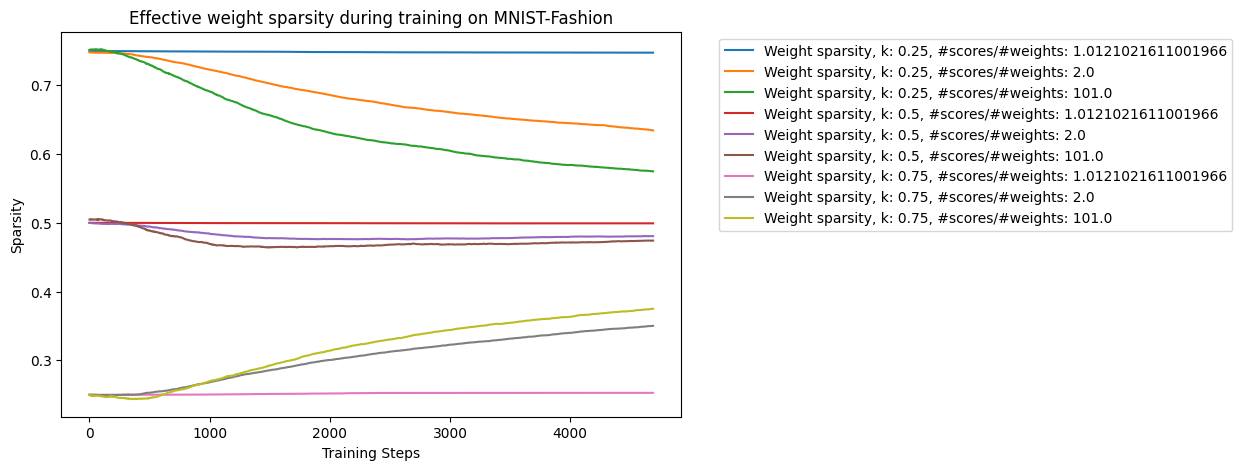

In [ ]:
# Experiment outline:
# 1. Sweep target sparsity k and score-capacity ratios.
# 2. Track effective realized weight sparsity after every training step.
# 3. Plot sparsity trajectories for all settings.

epochs = 5
batch_size = 64
layer_sizes=[[28*28,32],[32,10]]
extra_capacities=[0.01, 1.0, 100]
ks=[0.25,0.5,0.75]

def get_effective_weight_sparsity(model):
    total_zeros = 0
    total_weights = 0

    for layer in model.layers:
        if isinstance(layer,LinearSubnet):
            mask = GetSubnet.apply(layer.scores.abs(), layer.k)[:, :layer.weight.shape[-1]]
            bmask = GetSubnet.apply(layer.bias_scores.abs(), layer.k)[0,:layer.bias.shape[-1]]
            total_zeros += (layer.weight.data*mask == 0).sum().item()+(layer.bias.data*bmask==0).sum().item()
            total_weights += layer.weight.numel()+layer.bias.numel()
    return total_zeros / total_weights if total_weights > 0 else 0.0

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
train_dataloader = DataLoader(training_data, batch_size=batch_size)
loss_fn = nn.CrossEntropyLoss()
losses_extra_capacity = {k:{cap:[] for cap in extra_capacities} for k in ks}
sparsity_extra_capacity={k:{cap:[] for cap in extra_capacities} for k in ks}
weights_over_scores={k:{cap:{'weights':0,'scores':0} for cap in extra_capacities} for k in ks}
for k in ks:
  for cap in extra_capacities:
    model_extra_capacity = Network(layer_sizes, k=k, extra_capacity=cap)
    model_extra_capacity.to(device)
    weights_over_scores[k][cap]['weights'] = sum(
        layer.weight.numel() + layer.bias.numel()
        for layer in model_extra_capacity.layers
        if isinstance(layer, LinearSubnet)
    )
    weights_over_scores[k][cap]['scores'] = sum(
        layer.scores.numel() + layer.bias_scores.numel()
        for layer in model_extra_capacity.layers
        if isinstance(layer, LinearSubnet)
    )
    optimizer_extra_capacity = torch.optim.Adam(model_extra_capacity.parameters())
    for t in range(epochs):
        # print(f"Epoch {t+1}\n")
        model_extra_capacity.train()
        for (X, y) in train_dataloader:
            X,y = X.to(device), y.to(device)
            optimizer_extra_capacity.zero_grad()
            pred_extra_capacity = model_extra_capacity(X)
            loss_extra_capacity = loss_fn(pred_extra_capacity, y)
            losses_extra_capacity[k][cap].append(loss_extra_capacity.item())
            sparsity_extra_capacity[k][cap].append(get_effective_weight_sparsity(model_extra_capacity))
            loss_extra_capacity.backward()
            optimizer_extra_capacity.step()
plt.figure(figsize=(8, 5))
for k in ks:
  for cap in extra_capacities:
    score_to_weight_ratio = int(
        weights_over_scores[k][cap]['scores'] / weights_over_scores[k][cap]['weights']
    )
    plt.plot(
        sparsity_extra_capacity[k][cap],
        label=f'Weight sparsity, k: {k}, #scores/#weights: {score_to_weight_ratio}',
    )
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title(f"Effective weight sparsity during training on MNIST-Fashion")
plt.xlabel("Training Steps")
plt.ylabel("Sparsity")
plt.show()